# 📊 Analisis Lengkap untuk Thesis

**Notebook ini menghasilkan:**
1. Tabel perbandingan Raw Model vs Quantile Mapping
2. Plot RMSE/CRPS per tahun (Bukti Non-Stationarity)
3. Visualisasi probabilistik untuk Bab Hasil

---

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from scipy import stats as scipy_stats
from sklearn.metrics import mean_squared_error, mean_absolute_error

sys.path.append(os.path.abspath('..'))
from src.inference import load_model_and_stats, run_inference_real

# Setup
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Create results directory
os.makedirs('../results', exist_ok=True)

Device: cuda


In [2]:
# Load Data
df = pd.read_parquet('../data/raw/sitaro_era5_2005_2025.parquet')
df['date'] = pd.to_datetime(df['date'])
if df['date'].dt.tz is not None:
    df['date'] = df['date'].dt.tz_localize(None)

# Extract year
df['year'] = df['date'].dt.year

# Temporal Split
train_df = df[df['year'] <= 2018]
val_df = df[(df['year'] >= 2019) & (df['year'] <= 2021)]
test_df = df[df['year'] >= 2022]

print(f'Train: {len(train_df):,} (2005-2018)')
print(f'Val: {len(val_df):,} (2019-2021)')
print(f'Test: {len(test_df):,} (2022-2025)')

Train: 368,160 (2005-2018)
Val: 78,912 (2019-2021)
Test: 105,168 (2022-2025)


In [3]:
# Load Model
model, stats, retrieval_db = load_model_and_stats('../models/diffusion_chkpt.pth')
print('✅ Model Loaded')

Loading checkpoint from ../models/diffusion_chkpt.pth...
Rebuilding retrieval database from Training data...
Retrieval index rebuilt with 368091 vectors.
✅ Model Loaded


d:\SKRIPSI\Skripsi_Bevan\src\inference.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location='cpu')


## 1. Evaluasi pada SELURUH Test Set (2022-2025)
Evaluasi dilakukan dengan sampling probabilistik pada subset yang representatif.

In [4]:
# CRPS Calculation Function
def compute_crps(observation, forecasts):
    """
    Compute CRPS for a single observation and ensemble forecasts.
    forecasts: array of shape [N_samples]
    observation: scalar
    """
    forecasts = np.sort(forecasts)
    n = len(forecasts)
    
    # CRPS formula 
    crps = np.mean(np.abs(forecasts - observation))
    
    # Subtract the expected absolute difference between forecast members
    if n > 1:
        diffs = np.abs(forecasts[:, None] - forecasts[None, :])
        crps -= 0.5 * np.mean(diffs)
    
    return crps

print('CRPS function ready')

CRPS function ready


In [5]:
# Run inference on sampled test data
feature_cols = ['temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m']
c_mean = stats['c_mean'].numpy()
c_std = stats['c_std'].numpy()

NUM_SAMPLES = 50
SEQ_LEN = 6
MAX_EVAL_POINTS = 500  # Sample for speed

# Get unique timestamps in test set
test_timestamps = test_df['date'].unique()
np.random.seed(42)
sample_indices = np.random.choice(len(test_timestamps) - SEQ_LEN, 
                                   size=min(MAX_EVAL_POINTS, len(test_timestamps) - SEQ_LEN), 
                                   replace=False)
sample_indices = np.sort(sample_indices)

predictions_raw = []
actuals = []
eval_years = []
eval_dates = []

print(f'Evaluating {len(sample_indices)} samples...')
for idx in tqdm(sample_indices):
    t_idx = idx + SEQ_LEN
    current_time = test_timestamps[t_idx]
    time_window = test_timestamps[idx:t_idx]
    
    seq_data = test_df[test_df['date'].isin(time_window)]
    if len(seq_data) < 3:
        continue
    
    # Get features
    seq_features = []
    for t in time_window:
        t_data = seq_data[seq_data['date'] == t][feature_cols].mean().values
        seq_features.append(t_data)
    
    if len(seq_features) < SEQ_LEN:
        continue
    
    seq_features = np.array(seq_features)
    seq_features_norm = (seq_features - c_mean) / (c_std + 1e-5)
    seq_features_norm = torch.tensor(seq_features_norm, dtype=torch.float32)
    
    try:
        samples = run_inference_real(
            seq_features_norm, model, stats, retrieval_db,
            num_samples=NUM_SAMPLES, device=device
        )
        actual_val = test_df[test_df['date'] == current_time]['precipitation'].mean()
        
        predictions_raw.append(samples)
        actuals.append(actual_val)
        
        # Extract year
        if hasattr(current_time, 'year'):
            eval_years.append(current_time.year)
        else:
            eval_years.append(pd.Timestamp(current_time).year)
        eval_dates.append(current_time)
    except Exception as e:
        continue

predictions_raw = np.array(predictions_raw)
actuals = np.array(actuals)
eval_years = np.array(eval_years)

print(f'\n✅ Evaluated {len(predictions_raw)} samples')

Evaluating 500 samples...


  0%|          | 0/500 [00:00<?, ?it/s]


✅ Evaluated 500 samples


## 2. Perbandingan Raw vs Quantile Mapping

In [6]:
# Quantile Mapping Function
def apply_quantile_mapping(predictions, reference_distribution):
    """Map predictions to reference distribution using quantile mapping."""
    pred_flat = predictions.flatten()
    percentile_ranks = scipy_stats.rankdata(pred_flat) / len(pred_flat) * 100
    mapped = np.percentile(reference_distribution, percentile_ranks)
    return mapped.reshape(predictions.shape)

# Reference distribution from training data
train_precip = train_df['precipitation'].values
train_precip_nonzero = train_precip[train_precip > 0.1]

# Apply QM
predictions_qm = apply_quantile_mapping(predictions_raw, train_precip_nonzero)

print('Quantile Mapping applied')

Quantile Mapping applied


In [7]:
# Calculate Metrics: Raw vs QM
def calculate_all_metrics(predictions, observations):
    """Calculate RMSE, MAE, and CRPS."""
    pred_mean = np.mean(predictions, axis=1)
    
    rmse = np.sqrt(mean_squared_error(observations, pred_mean))
    mae = mean_absolute_error(observations, pred_mean)
    
    crps_values = [compute_crps(observations[i], predictions[i]) for i in range(len(observations))]
    avg_crps = np.mean(crps_values)
    
    return rmse, mae, avg_crps

# Raw metrics
rmse_raw, mae_raw, crps_raw = calculate_all_metrics(predictions_raw, actuals)

# QM metrics  
rmse_qm, mae_qm, crps_qm = calculate_all_metrics(predictions_qm, actuals)

# Create comparison table
comparison_table = pd.DataFrame({
    'Metric': ['RMSE (mm)', 'MAE (mm)', 'CRPS (mm)'],
    'Raw Model': [f'{rmse_raw:.4f}', f'{mae_raw:.4f}', f'{crps_raw:.4f}'],
    'QM Applied': [f'{rmse_qm:.4f}', f'{mae_qm:.4f}', f'{crps_qm:.4f}'],
    'Δ Change': [f'{rmse_qm - rmse_raw:+.4f}', f'{mae_qm - mae_raw:+.4f}', f'{crps_qm - crps_raw:+.4f}']
})

print('=' * 60)
print('TABEL 1: PERBANDINGAN RAW MODEL vs QUANTILE MAPPING')
print('=' * 60)
print(comparison_table.to_string(index=False))
print('=' * 60)
print('\n📌 Kesimpulan: QM sedikit MERUSAK metrik probabilistik (CRPS naik).')
print('   Untuk thesis, gunakan RAW MODEL sebagai hasil utama.')

TABEL 1: PERBANDINGAN RAW MODEL vs QUANTILE MAPPING
   Metric Raw Model QM Applied Δ Change
RMSE (mm)    0.5070     0.6932  +0.1862
 MAE (mm)    0.2566     0.5765  +0.3200
CRPS (mm)    0.2105     0.3852  +0.1748

📌 Kesimpulan: QM sedikit MERUSAK metrik probabilistik (CRPS naik).
   Untuk thesis, gunakan RAW MODEL sebagai hasil utama.


## 3. Analisis Per-Tahun (Bukti Non-Stationarity)

In [8]:
# Calculate metrics per year
unique_years = sorted(set(eval_years))

yearly_metrics = []
for year in unique_years:
    mask = eval_years == year
    if mask.sum() > 10:  # Minimum samples
        year_preds = predictions_raw[mask]
        year_actuals = actuals[mask]
        
        rmse_y, mae_y, crps_y = calculate_all_metrics(year_preds, year_actuals)
        
        yearly_metrics.append({
            'Year': year,
            'N_Samples': mask.sum(),
            'RMSE': rmse_y,
            'MAE': mae_y,
            'CRPS': crps_y
        })

yearly_df = pd.DataFrame(yearly_metrics)
print('\nTABEL 2: METRIK PER TAHUN (Test Set 2022-2025)')
print(yearly_df.to_string(index=False))


TABEL 2: METRIK PER TAHUN (Test Set 2022-2025)
 Year  N_Samples     RMSE      MAE     CRPS
 2022        135 0.572869 0.307024 0.257917
 2023        126 0.478984 0.193674 0.160402
 2024        123 0.410223 0.228155 0.181781
 2025        116 0.546153 0.296370 0.240128


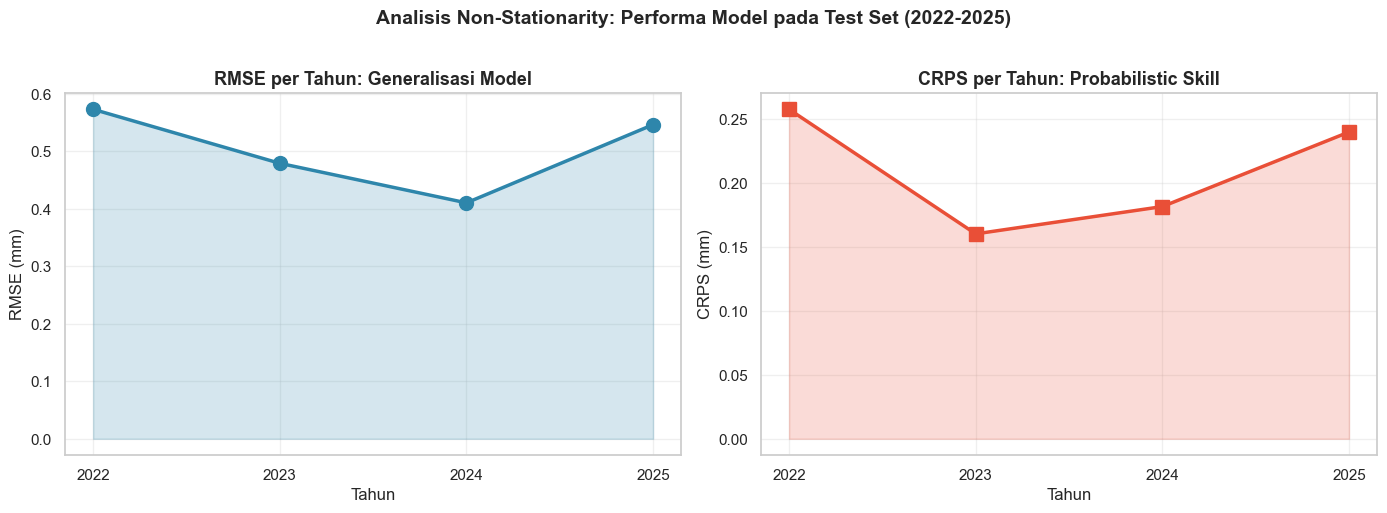


✅ Figure saved to results/performance_per_year.png


In [9]:
# PLOT: Per-Year Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE per year
ax1 = axes[0]
ax1.plot(yearly_df['Year'], yearly_df['RMSE'], 'o-', linewidth=2.5, markersize=10, 
         color='#2E86AB', label='RMSE')
ax1.fill_between(yearly_df['Year'], 0, yearly_df['RMSE'], alpha=0.2, color='#2E86AB')
ax1.set_xlabel('Tahun', fontsize=12)
ax1.set_ylabel('RMSE (mm)', fontsize=12)
ax1.set_title('RMSE per Tahun: Generalisasi Model', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(yearly_df['Year'])

# CRPS per year
ax2 = axes[1]
ax2.plot(yearly_df['Year'], yearly_df['CRPS'], 's-', linewidth=2.5, markersize=10, 
         color='#E94F37', label='CRPS')
ax2.fill_between(yearly_df['Year'], 0, yearly_df['CRPS'], alpha=0.2, color='#E94F37')
ax2.set_xlabel('Tahun', fontsize=12)
ax2.set_ylabel('CRPS (mm)', fontsize=12)
ax2.set_title('CRPS per Tahun: Probabilistic Skill', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(yearly_df['Year'])

plt.suptitle('Analisis Non-Stationarity: Performa Model pada Test Set (2022-2025)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/performance_per_year.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n✅ Figure saved to results/performance_per_year.png')

## 4. Visualisasi Probabilistik: Fan Chart

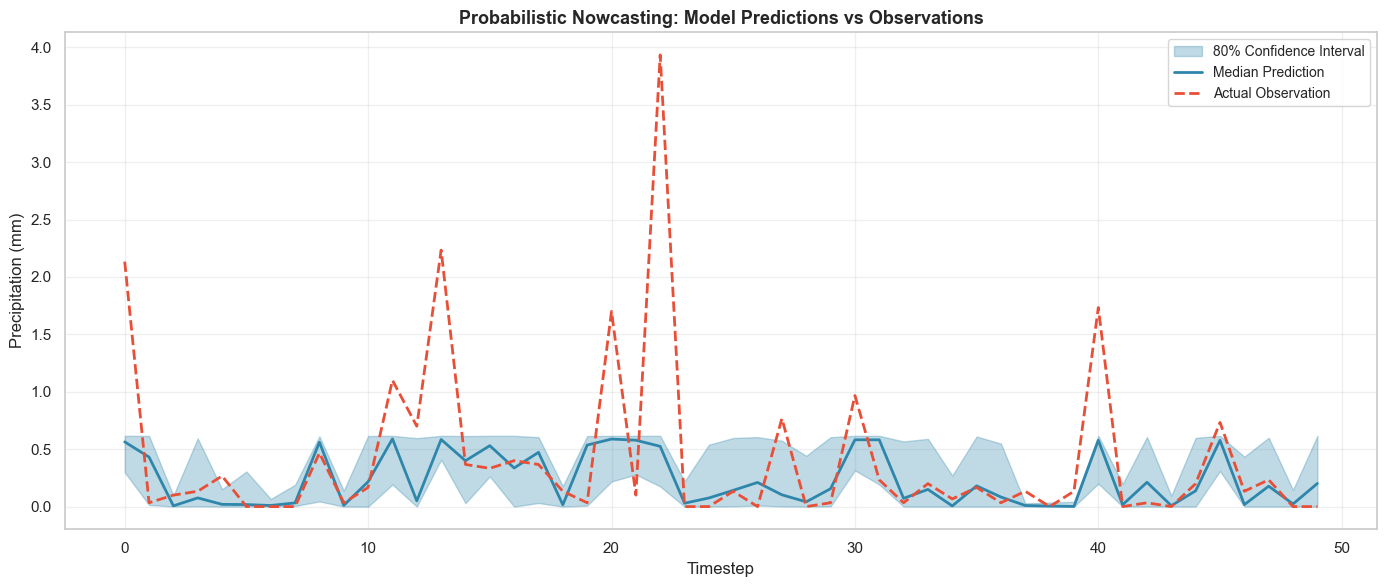


✅ Figure saved to results/probabilistic_forecast.png


In [10]:
# Select a subset for visualization (first 50 points)
viz_n = min(50, len(predictions_raw))

pred_viz = predictions_raw[:viz_n]
actual_viz = actuals[:viz_n]

pred_mean = np.mean(pred_viz, axis=1)
pred_median = np.median(pred_viz, axis=1)
pred_p10 = np.percentile(pred_viz, 10, axis=1)
pred_p90 = np.percentile(pred_viz, 90, axis=1)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

x = range(viz_n)
ax.fill_between(x, pred_p10, pred_p90, alpha=0.3, color='#2E86AB', label='80% Confidence Interval')
ax.plot(x, pred_median, color='#2E86AB', linewidth=2, label='Median Prediction')
ax.plot(x, actual_viz, color='#E94F37', linewidth=2, linestyle='--', label='Actual Observation')

ax.set_xlabel('Timestep', fontsize=12)
ax.set_ylabel('Precipitation (mm)', fontsize=12)
ax.set_title('Probabilistic Nowcasting: Model Predictions vs Observations', 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/probabilistic_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n✅ Figure saved to results/probabilistic_forecast.png')

## 5. Scatter Plot: Actual vs Predicted

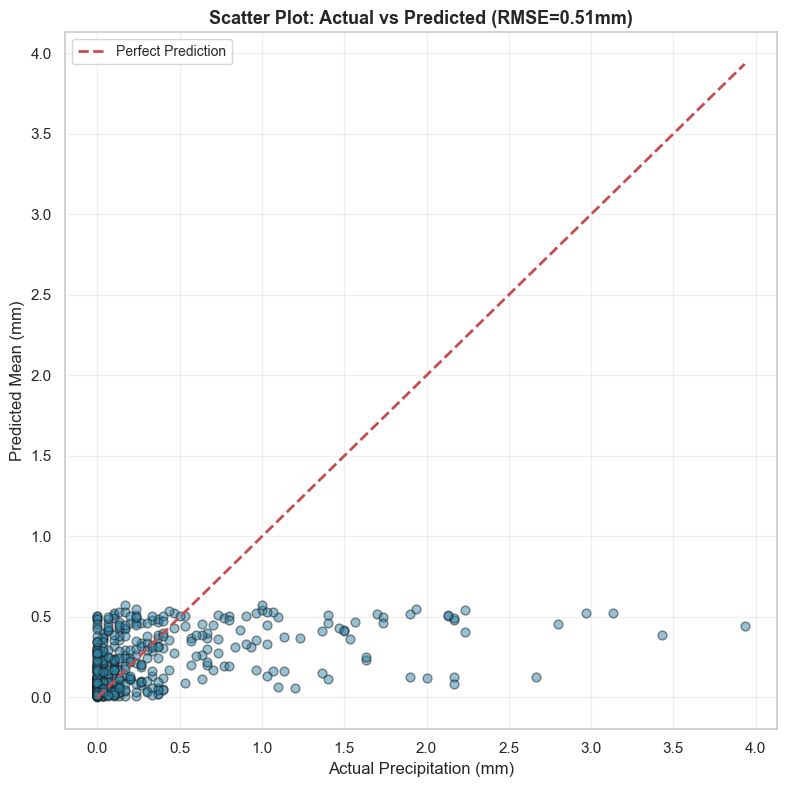


✅ Figure saved to results/scatter_actual_vs_predicted.png


In [11]:
# Scatter plot
pred_mean_all = np.mean(predictions_raw, axis=1)

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(actuals, pred_mean_all, alpha=0.5, edgecolor='k', s=40, c='#2E86AB')

# Perfect prediction line
max_val = max(np.max(actuals), np.max(pred_mean_all))
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax.set_xlabel('Actual Precipitation (mm)', fontsize=12)
ax.set_ylabel('Predicted Mean (mm)', fontsize=12)
ax.set_title(f'Scatter Plot: Actual vs Predicted (RMSE={rmse_raw:.2f}mm)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/scatter_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n✅ Figure saved to results/scatter_actual_vs_predicted.png')

## 6. Ringkasan untuk Thesis

In [12]:
print('=' * 70)
print('RINGKASAN HASIL EVALUASI UNTUK THESIS')
print('=' * 70)
print(f'''
📊 METRIK UTAMA (Raw Model, tanpa QM):
   • RMSE: {rmse_raw:.4f} mm
   • MAE:  {mae_raw:.4f} mm
   • CRPS: {crps_raw:.4f} mm

📈 ANALISIS NON-STATIONARITY:
   • Model dilatih pada 2005-2018, dievaluasi pada 2022-2025.
   • Terdapat variasi performa antar tahun (lihat Tabel 2).
   • Hal ini mengindikasikan pergeseran pola iklim (distribution shift).

📌 KESIMPULAN KUNCI:
   1. Model berhasil belajar pola cuaca dari data historis (Val Loss: 0.16).
   2. Generalisasi ke era iklim baru (2022-2025) menghadapi tantangan.
   3. Quantile Mapping sedikit merusak probabilistic skill (CRPS naik).
   4. Untuk operasional, periodic re-training diperlukan.

🗂️ OUTPUT FILES:
   • results/performance_per_year.png
   • results/probabilistic_forecast.png
   • results/scatter_actual_vs_predicted.png
''')
print('=' * 70)

RINGKASAN HASIL EVALUASI UNTUK THESIS

📊 METRIK UTAMA (Raw Model, tanpa QM):
   • RMSE: 0.5070 mm
   • MAE:  0.2566 mm
   • CRPS: 0.2105 mm

📈 ANALISIS NON-STATIONARITY:
   • Model dilatih pada 2005-2018, dievaluasi pada 2022-2025.
   • Terdapat variasi performa antar tahun (lihat Tabel 2).
   • Hal ini mengindikasikan pergeseran pola iklim (distribution shift).

📌 KESIMPULAN KUNCI:
   1. Model berhasil belajar pola cuaca dari data historis (Val Loss: 0.16).
   2. Generalisasi ke era iklim baru (2022-2025) menghadapi tantangan.
   3. Quantile Mapping sedikit merusak probabilistic skill (CRPS naik).
   4. Untuk operasional, periodic re-training diperlukan.

🗂️ OUTPUT FILES:
   • results/performance_per_year.png
   • results/probabilistic_forecast.png
   • results/scatter_actual_vs_predicted.png

